# Plot sea ice coverage over time (FLOR, CM2.1)

Figure 3, S5

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
plt.style.use('../func/PPT.mplstyle')

In [2]:
from misc_func import find_files

## Model and experiment names

In [3]:
modelnames = ['FLOR', 'CM2.1p1']

variable = 'MI'

def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
             'p6p0sol_CTL1860',
#                 'p4p0sol_CTL1860',
#                 'p2p0sol_CTL1860', 
#                 'p1p0sol_CTL1860',
#                 'CTL1860_newdiag',
#                 'm1p0sol_CTL1860', 
#                 'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',]
        modelstr = 'FLOR'

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
             'CTL1860_p6pctSolar', 
#                 'CTL1860_p4pctSolar',
#                 'CTL1860_p2pctSolar',
#                 'CTL1860_p1pctSolar',
#                 'CTL1860',
#                 'CTL1860_m1pctSolar',
#                 'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',]
        modelstr = 'CM2.1'
    return exps, extension, modelstr

In [4]:
def count_ice_months(da):
    # count months in year that have ice mass > 1 kg
    
    # nan mask
    mask = xr.ufuncs.isnan(da.isel(time=0).squeeze())
    
    nyrs = int(np.size(da.time) / 12)
    
    count_array = np.empty((nyrs-1,np.size(da.yt),np.size(da.xt)))

    import time
    start_time = time.time()
    
    for ii in tqdm(range(nyrs-1)): # count for each year
        
        # select year
        temp = da.isel(time=slice(ii*12,(ii+1)*12))
        count = (temp > 1).sum('time') # get lat/lon map with sum of months >1
        count_array[ii,:,:] = count # save into numpy array
        
        if ii % 10 == 0:
            print(f'{ii/nyrs*100}% complete')
            elapsed_time = (time.time() - start_time) / 60
            print(f"Elapsed time: {elapsed_time:.2f} minutes")
        
    # put into xarray
    count_xr = xr.DataArray(data=count_array,
                           dims=('year', 'yt', 'xt'),
                          coords={'year': np.arange(1,nyrs,1), 'yt': da.yt, 'xt': da.xt})
    
    # apply nan mask
    count_xr_masked = xr.where(mask, np.nan, count_xr)
    
    return count_xr_masked

In [5]:
for ii in range(np.size(modelnames)):

    exps, extension, modelstr = get_experiment_names(modelnames[ii])
    
    for iexp in range(np.size(exps)):
        
        print(modelnames[ii], exps[iexp])

        # if already made this calculation, skip
        fileo = f'count_ice_months_{variable}_{modelnames[ii]}_{exps[iexp]}.nc'
        ifile = find_files(f'./processed_data/', 
                           f'count_ice_months_{variable}_{modelnames[ii]}_{exps[iexp]}.nc')
        if ifile != None:
            print(f'Already exists: {ifile}')
            continue
        
        directory = 'MODEL_OUT'
        ifile = find_files(f'/tigress/mvchung/ANALYSIS/Solar_NEW/{directory}/',
                                            f'{variable}_{modelnames[ii]}_{exps[iexp]}_{extension}')
        if ifile == None: # if there is no MI data detected
            print('No ice mass data found in ./MODEL_OUT')
            continue
        da = xr.open_dataarray(f'./{directory}/{ifile}')
    
        #da_sum = da.sum('xt')
        
        # Count months where values are greater than 1
        months_ice_da = count_ice_months(da)
        
        months_ice_da.to_netcdf(f'./processed_data/count_ice_months_{variable}_{modelnames[ii]}_{exps[iexp]}.nc')
        
        #print(months_ice_da)
    

FLOR p6p0sol_CTL1860
Already exists: count_ice_months_MI_FLOR_p6p0sol_CTL1860.nc
FLOR m4p0sol_CTL1860
Already exists: count_ice_months_MI_FLOR_m4p0sol_CTL1860.nc
FLOR m6p0sol_CTL1860
Already exists: count_ice_months_MI_FLOR_m6p0sol_CTL1860.nc
CM2.1p1 CTL1860_p6pctSolar
Already exists: count_ice_months_MI_CM2.1p1_CTL1860_p6pctSolar.nc
CM2.1p1 CTL1860_m4pctSolar
Already exists: count_ice_months_MI_CM2.1p1_CTL1860_m4pctSolar.nc
CM2.1p1 CTL1860_m6pctSolar
Already exists: count_ice_months_MI_CM2.1p1_CTL1860_m6pctSolar.nc


## load ice months per year data

In [6]:
# load data

FLOR_m4_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_FLOR_m4p0sol_CTL1860.nc')
FLOR_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_FLOR_m6p0sol_CTL1860.nc')

CM21_m4_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_CM2.1p1_CTL1860_m4pctSolar.nc')
CM21_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_CM2.1p1_CTL1860_m6pctSolar.nc')

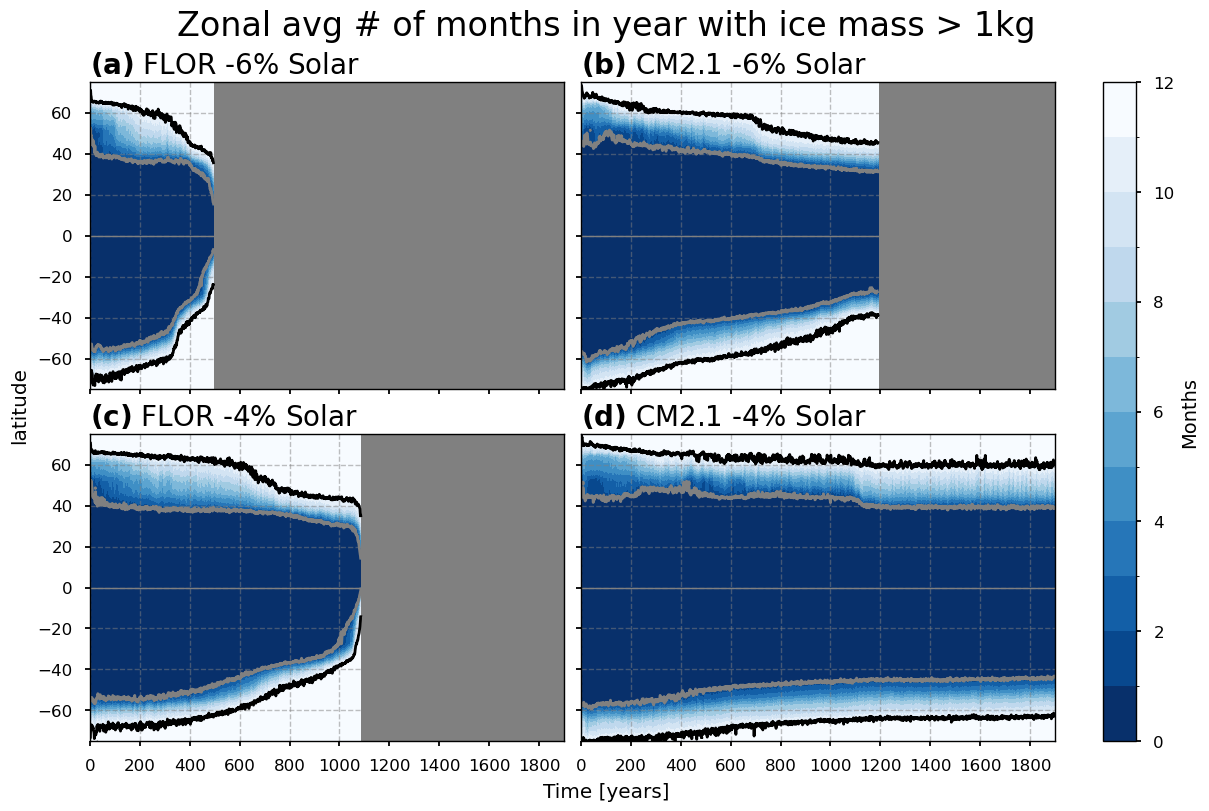

In [11]:
# plot months of year where ice mass>1

window = 1

fig, ax = plt.subplots(2,2,sharex=True,sharey=True,constrained_layout=True,figsize=(12,8))

axis = ax[0,0]
ctr = FLOR_m6_ice_months.mean('xt').plot.contourf(ax=axis,x='year',cmap='Blues_r',levels=13,add_colorbar=False,
                                              zorder=0)
FLOR_m6_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1)
FLOR_m6_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1)
axis.set_title('')
axis.set_title(r'$\bf{(a)}$ FLOR -6% Solar', loc='left')



axis = ax[0,1]
ctr = CM21_m6_ice_months.mean('xt').plot.contourf(ax=axis,x='year',cmap='Blues_r',levels=13,add_colorbar=False,
                                              zorder=0)
CM21_m6_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1)
CM21_m6_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1)
axis.set_title('')
axis.set_title(r'$\bf{(b)}$ CM2.1 -6% Solar', loc='left')

axis = ax[1,0]
ctr = FLOR_m4_ice_months.mean('xt').plot.contourf(ax=axis,x='year',cmap='Blues_r',levels=13,add_colorbar=False,
                                              zorder=0)
FLOR_m4_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1)
FLOR_m4_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1)
axis.set_title('')
axis.set_title(r'$\bf{(c)}$ FLOR -4% Solar', loc='left')



axis = ax[1,1]
ctr = CM21_m4_ice_months.mean('xt').plot.contourf(ax=axis,x='year',cmap='Blues_r',levels=13,add_colorbar=False,
                                              zorder=0)
CM21_m4_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1)
CM21_m4_ice_months.rolling(year=window,center='True').mean('time').mean('xt').plot.contour(ax=axis,x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1)
axis.set_title('')
axis.set_title(r'$\bf{(d)}$ CM2.1 -4% Solar', loc='left')

cb = fig.colorbar(ctr, ax=ax[:], label='Months')

for axis in ax.flatten():
    axis.grid(zorder=1,alpha=0.5)
    axis.set_ylabel('')
    axis.set_xlabel('')
    axis.axhline(0,color='gray',linewidth=1)
    axis.set_facecolor('gray')
    axis.set_ylim(-75,75)
    axis.set_xticks(np.arange(0,1900,200))

fig.supxlabel('Time [years]')
fig.supylabel('latitude')
fig.suptitle('Zonal avg # of months in year with ice mass > 1kg')

plt.savefig('Figure3.pdf')

# North Pacific only

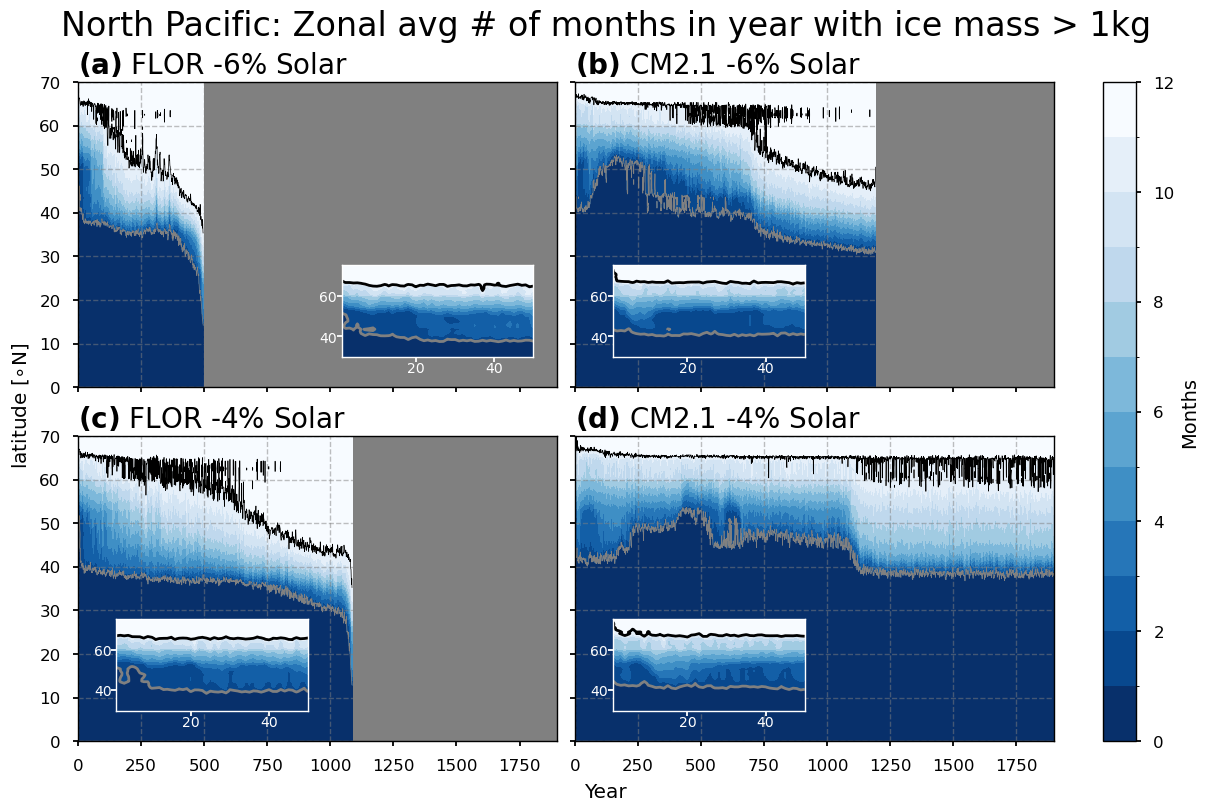

In [12]:
# do it for north pacific only
# plot months of year where ice mass>1

window = 1 # rolling mean(years)

fig, ax = plt.subplots(2,2,sharex=True,sharey=True,constrained_layout=True,figsize=(12,8))

ctr = FLOR_m6_ice_months.sel(xt=slice(120-360,-100),yt=slice(0,None)).mean('xt').plot.contourf(ax=ax[0,0],x='year',cmap='Blues_r',levels=13,add_colorbar=False,
                                              zorder=0)
FLOR_m6_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[0,0],x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1, linewidths=0.5)
FLOR_m6_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[0,0],x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1, linewidths=0.5)


ctr = CM21_m6_ice_months.sel(xt=slice(120-360,-100),yt=slice(0,None)).mean('xt').plot.contourf(ax=ax[0,1],x='year',cmap='Blues_r',levels=13,add_colorbar=False,zorder=0)
CM21_m6_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[0,1],x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1, linewidths=0.5)
CM21_m6_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[0,1],x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1, linewidths=0.5)


ctr = FLOR_m4_ice_months.sel(xt=slice(120-360,-100),yt=slice(0,None)).mean('xt').plot.contourf(ax=ax[1,0],x='year',cmap='Blues_r',levels=13,add_colorbar=False,
                                              zorder=0)
FLOR_m4_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[1,0],x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1, linewidths=0.5)
FLOR_m4_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[1,0],x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1, linewidths=0.5)


ctr = CM21_m4_ice_months.sel(xt=slice(120-360,-100),yt=slice(0,None)).mean('xt').plot.contourf(ax=ax[1,1],x='year',cmap='Blues_r',levels=13,add_colorbar=False,zorder=0)
CM21_m4_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[1,1],x='year',
                                                                                     colors='black',levels=[11],add_colorbar=False,zorder=1, linewidths=0.5)
CM21_m4_ice_months.rolling(year=window,center='True').mean('time').sel(xt=slice(120-360,-100),
                                                  yt=slice(0,None)).mean('xt').plot.contour(ax=ax[1,1],x='year',
                                                                                     colors='gray',levels=[1],add_colorbar=False,zorder=1, linewidths=0.5)
for axis in ax.flatten():
    axis.set_title('')

ax[0,0].set_title(r'$\bf{(a)}$ FLOR -6% Solar', loc='left')
ax[0,1].set_title(r'$\bf{(b)}$ CM2.1 -6% Solar', loc='left')
ax[1,0].set_title(r'$\bf{(c)}$ FLOR -4% Solar', loc='left')
ax[1,1].set_title(r'$\bf{(d)}$ CM2.1 -4% Solar', loc='left')
ax[0,0].set_ylabel('-6% Solar')
ax[0,0].set_ylabel('-4% Solar')

cb = fig.colorbar(ctr, ax=ax[:], label='Months')

for axis in ax.flatten():
    axis.grid(zorder=1,alpha=0.5)
    axis.set_ylabel('')
    axis.set_xlabel('')
    axis.axhline(0,color='gray',linewidth=1)
    axis.set_facecolor('gray')
    axis.set_ylim(0,70)
    axis.set_xlim(0,1900)

fig.supxlabel('Year')
fig.supylabel(r'latitude [$\circ$N]')
fig.suptitle('North Pacific: Zonal avg # of months in year with ice mass > 1kg')

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Helper function to add inset showing first 50 years with rolling mean
def add_inset(ax_main, data_array):
    
    # Use a different position for different subplots
    if ax_main == ax[0,0]:
        loc = 'lower right'
        bbox = (-0.05, 0.1, 1, 1)  
    else:
        loc = 'lower left'
        bbox = (0.08, 0.1, 1, 1)

    axin = inset_axes(ax_main, width="40%", height="30%", loc=loc,
                      bbox_to_anchor=bbox, bbox_transform=ax_main.transAxes, borderpad=0)

    data_subset = data_array.sel(xt=slice(120-360, -100), yt=slice(0, None)).mean('xt')
    data_subset = data_subset.sel(year=slice(0, 50))  # First 50 years
    data_subset.plot.contourf(ax=axin, x='year',cmap='Blues_r',levels=13,add_colorbar=False,zorder=0)
    data_subset.plot.contour(ax=axin, x='year',colors='k',levels=[11],add_colorbar=False,zorder=1)
    data_subset.plot.contour(ax=axin, x='year',colors='gray',levels=[1],add_colorbar=False,zorder=1)
    
    axin.set_title('')
    axin.set_xlabel('')
    axin.set_ylabel('')
    axin.set_xlim(1, 50)
    axin.set_ylim(30, 75)
    axin.tick_params(labelsize=6, pad=0)

    # Tick marks and labels
    axin.tick_params(colors='white', labelsize=10)
    for label in axin.get_xticklabels() + axin.get_yticklabels():
        label.set_color('white')
    
    # Axis spines (frame)
    for spine in axin.spines.values():
        spine.set_edgecolor('white')

# Add insets for each subplot
add_inset(ax[0,0], FLOR_m6_ice_months)
add_inset(ax[0,1], CM21_m6_ice_months)
add_inset(ax[1,0], FLOR_m4_ice_months)
add_inset(ax[1,1], CM21_m4_ice_months)

plt.savefig('FigureS4.pdf')